In [2]:
import pandas as pd

churn_dataset = pd.read_csv("../data/processed/churn_dataset.csv")
revenue_dataset = pd.read_csv("../data/processed/revenue_dataset.csv")

churn_dataset.head()

,recency_days,frequency_orders,monetary_total,total_items,unique_products,avg_order_value,churn_label
0,235,2,0.00,0,1,0.000000,1
1,39,5,2790.86,1590,82,558.172000,0
2,158,3,1487.24,2124,22,495.746667,0
3,220,1,334.40,197,17,334.400000,1
4,172,8,601.18,188,26,75.147500,0


In [3]:
X_churn = churn_dataset.drop(columns=["churn_label"])
y_churn = churn_dataset["churn_label"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_churn,
    y_churn,
    test_size=0.2,
    random_state=42
)

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test)

c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [7]:
from sklearn.metrics import accuracy_score

log_accuracy = accuracy_score(y_test, y_pred_log)
log_accuracy

0.6149341142020498

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(random_state=42)

rf_clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
y_pred = rf_clf.predict(X_test)

In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

accuracy

0.6251830161054173

In [11]:
from sklearn.model_selection import cross_val_score

log_scores = cross_val_score(
    log_reg,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

log_scores

array([0.70695971, 0.67765568, 0.7014652 , 0.67399267, 0.67889908])

In [12]:
log_reg_acc=log_scores.mean()

In [13]:
log_reg_acc

np.float64(0.6877944685284134)

In [14]:
log_scores.std()

np.float64(0.013613286210871375)

In [15]:
rf_scores = cross_val_score(
    rf_clf,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

rf_scores

array([0.66666667, 0.62820513, 0.63003663, 0.67216117, 0.65504587])

In [16]:
rf_acc=rf_scores.mean()

In [17]:
rf_acc

np.float64(0.650423093725846)

In [18]:
rf_scores.std()

np.float64(0.018259319179401153)

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_clf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_clf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    refit=True
)

grid_search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [20]:
grid_search.best_params_

{'max_depth': 10,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 200}

In [21]:
grid_search.best_score_

np.float64(0.6815646738582519)

In [22]:
best_rf_model = grid_search.best_estimator_
best_rf_model

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
from sklearn.metrics import accuracy_score

y_pred_best_rf = best_rf_model.predict(X_test)
best_rf_test_accuracy = accuracy_score(y_test, y_pred_best_rf)

best_rf_test_accuracy

0.6500732064421669

In [24]:
print("Logistic Regression Test Accuracy:", log_reg_acc)
print("Random Forest Default Test Accuracy:", rf_acc)
print("Best Random Forest CV Score:", grid_search.best_score_)
print("Best Random Forest Test Accuracy:", best_rf_test_accuracy)
print("Best Parameters:", grid_search.best_params_)

Logistic Regression Test Accuracy: 0.6877944685284134
Random Forest Default Test Accuracy: 0.650423093725846
Best Random Forest CV Score: 0.6815646738582519
Best Random Forest Test Accuracy: 0.6500732064421669
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [25]:
import pandas as pd

cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results = cv_results.sort_values(by="mean_test_score", ascending=False)

cv_results[[
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_split",
    "param_min_samples_leaf",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].head(10)

,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,mean_test_score,std_test_score,rank_test_score
1,200,10,2,1,0.681565,0.013164,1
3,200,10,5,1,0.680093,0.020106,2
7,200,10,5,2,0.678265,0.013729,3
5,200,10,2,2,0.676067,0.013403,4
6,100,10,5,2,0.674959,0.022838,5
2,100,10,5,1,0.674232,0.013475,6
0,100,10,2,1,0.673134,0.017179,7
4,100,10,2,2,0.672035,0.015973,8
15,200,20,5,2,0.667638,0.017706,9
19,200,None,5,1,0.667637,0.015368,10


In [26]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_best_rf)

array([[269, 115],
       [124, 175]])

In [27]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    "n_estimators": randint(100, 500),
    "max_depth": randint(5, 30),
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5)
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': <scipy.stats....001B072565DE0>, 'min_samples_leaf': <scipy.stats....001B072592C50>, 'min_samples_split': <scipy.stats....001B0725D3610>, 'n_estimators': <scipy.stats....001B0725D3FA0>}"
,n_iter,20
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [28]:
random_search.best_params_

{'max_depth': 8,
 'min_samples_leaf': 4,
 'min_samples_split': 9,
 'n_estimators': 230}

In [29]:
random_search.best_score_

np.float64(0.6830278589911616)

In [30]:
best_ra_model = random_search.best_estimator_
best_ra_model

,n_estimators,230
,criterion,'gini'
,max_depth,8
,min_samples_split,9
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
from sklearn.metrics import accuracy_score

y_pred_best_ra = best_ra_model.predict(X_test)
best_ra_test_accuracy = accuracy_score(y_test, y_pred_best_ra)

best_ra_test_accuracy

0.6500732064421669

In [32]:
grid_pred = grid_search.best_estimator_.predict(X_test)
random_pred = random_search.best_estimator_.predict(X_test)

(grid_pred == random_pred).mean()

np.float64(0.9560761346998536)

In [33]:
import pandas as pd

feature_importances = best_rf_model.feature_importances_

features = X_train.columns

importance_df = pd.DataFrame({
    "feature": features,
    "importance": feature_importances
}).sort_values(by="importance", ascending=False)

importance_df

,feature,importance
2,monetary_total,0.204367
3,total_items,0.191668
0,recency_days,0.185308
4,unique_products,0.153082
5,avg_order_value,0.138926
1,frequency_orders,0.126650


<Axes: ylabel='feature'>

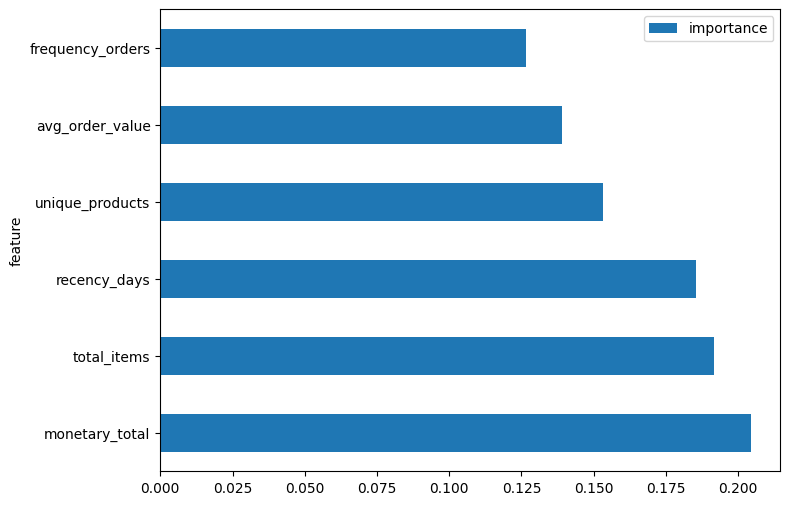

In [34]:
importance_df.plot(kind='barh', x='feature', y='importance', figsize=(8,6))

In [35]:
y_churn.value_counts()

churn_label
0    1958
1    1454
Name: count, dtype: int64

In [36]:
y_churn.value_counts(normalize=True)

churn_label
0    0.573857
1    0.426143
Name: proportion, dtype: float64

In [37]:
churn_rate = y_churn.mean()
print(churn_rate)

0.4261430246189918


## Churn Prediction as a Classification Problem

In this stage, the churn prediction task is formulated as a binary classification problem:

- 0 → Customer remains active  
- 1 → Customer churns  

The objective is to evaluate the model using classification metrics that provide deeper insights than accuracy, such as:

- Confusion Matrix  
- Precision  
- Recall  
- F1 Score  

These metrics help assess the model's ability to correctly identify customers who are likely to churn, which is critical for business decision-making.

## Binary Classification Setup

The churn prediction task is formulated as a binary classification problem, where the model predicts whether a customer will churn (1) or remain active (0).

Unlike generic examples, the target variable is already defined, so no transformation is required.

## Model Evaluation

Although accuracy provides a general indication of model performance, it may not fully capture the model's effectiveness in identifying churned customers.

In churn prediction, correctly identifying customers who are likely to leave is more critical than overall accuracy. Therefore, additional evaluation metrics such as confusion matrix, precision, recall, and F1-score are used to gain deeper insights into model performance.

In [38]:
from sklearn.model_selection import cross_val_predict

y_train_pred_rf = cross_val_predict(
    best_rf_model, 
    X_train, 
    y_train, 
    cv=5
)

In [39]:
from sklearn.metrics import confusion_matrix

cm_train = confusion_matrix(y_train, y_train_pred_rf)

cm_train

array([[1140,  434],
       [ 435,  720]])

In [40]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_train, y_train_pred_rf)
recall = recall_score(y_train, y_train_pred_rf)
f1 = f1_score(y_train, y_train_pred_rf)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.6239168110918544
Recall: 0.6233766233766234
F1 Score: 0.6236466002598527


## Precision, Recall, and F1 Score

To better understand model performance beyond accuracy, precision, recall, and F1-score are evaluated.

- Precision measures how reliable the churn predictions are.
- Recall measures how well the model identifies customers who actually churn.
- F1-score provides a balance between precision and recall.

failing to identify a customer who is about to churn may result in direct revenue loss and missed retention opportunities.
We avoid using the test set during model tuning to prevent overfitting to the test data.

## Model Selection Justification

Although Logistic Regression showed slightly higher accuracy, accuracy alone is not sufficient for evaluating churn models.

In churn prediction, recall is more important because failing to identify a customer who is likely to leave can result in direct revenue loss.

Random Forest was selected because it captures non-linear relationships better and provides feature importance, which helps in understanding customer behavior.

In [41]:
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import cross_val_predict


y_scores = cross_val_predict(
    best_rf_model,
    X_train,
    y_train,
    cv=5,
    method="predict_proba"
)


y_scores = y_scores[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)

Threshold selection depends on the business objective, not the metric itself.
In churn prediction, recall is often prioritized to avoid missing customers at risk, 
but we also ensure that precision remains at an acceptable level.

In [42]:
import numpy as np

idx = (precisions >= 0.8).argmax()
threshold_80 = thresholds[idx]

threshold_80

np.float64(0.888890732581728)

In [43]:
y_train_pred_custom = (y_scores >= threshold_80)

In [44]:
from sklearn.metrics import precision_score, recall_score

print("Precision:", precision_score(y_train, y_train_pred_custom))
print("Recall:", recall_score(y_train, y_train_pred_custom))

Precision: 0.8571428571428571
Recall: 0.005194805194805195


In [45]:
idx_recall = (recalls >= 0.7).argmax()
threshold_recall = thresholds[idx_recall]

threshold_recall

np.float64(0.0)

In [46]:
y_train_pred_recall = (y_scores >= threshold_recall)

In [47]:
print("Precision:", precision_score(y_train, y_train_pred_recall))
print("Recall:", recall_score(y_train, y_train_pred_recall))

Precision: 0.4232319530963723
Recall: 1.0


In [48]:
valid_idx = np.where(recalls >= 0.7)[0]
idx_recall = valid_idx[-1]
threshold_recall = thresholds[idx_recall]

threshold_recall

np.float64(0.44903935889121516)

In [49]:
y_train_pred_recall = (y_scores >= threshold_recall)

print("Precision:", precision_score(y_train, y_train_pred_recall))
print("Recall:", recall_score(y_train, y_train_pred_recall))
print("F1:", f1_score(y_train, y_train_pred_recall))

Precision: 0.6010401188707281
Recall: 0.7004329004329004
F1: 0.6469412235105958


Initially, I selected the threshold based on precision, which resulted in very low recall.
Since churn prediction requires identifying as many at-risk customers as possible, I adjusted the threshold based on recall.

I optimized the decision threshold to achieve around 70% recall while maintaining acceptable precision.
This approach aligns with business needs, where missing a churn customer is more costly than false positives.

## Precision-Recall Curve

The precision-recall curve was used to analyze the trade-off between identifying churned customers and controlling false positives.

Since missing a churn customer is costly, the decision threshold was adjusted to improve recall while keeping precision at an acceptable level.

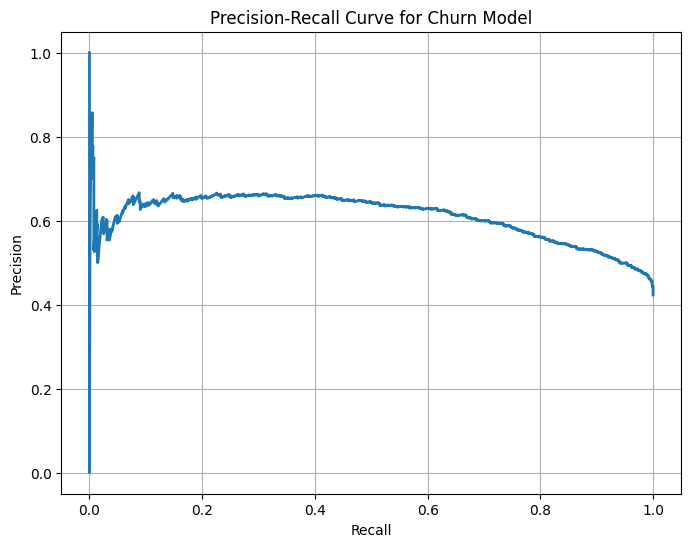

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Churn Model")
plt.grid(True)

plt.show()

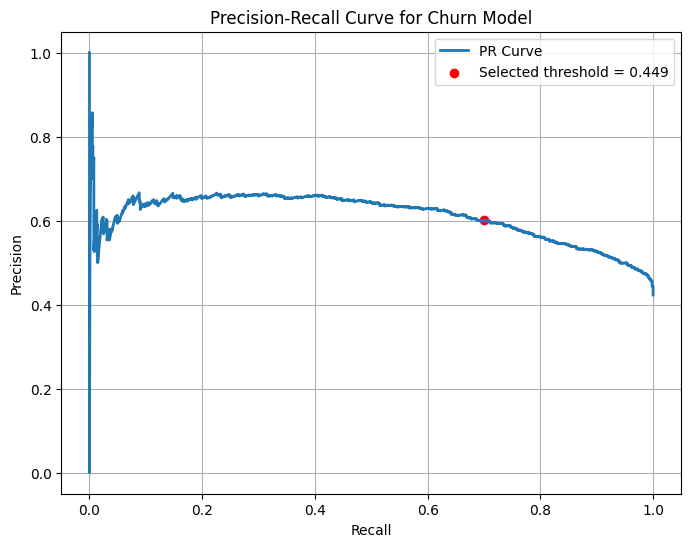

In [51]:
idx_selected = idx_recall

plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, linewidth=2, label="PR Curve")
plt.scatter(
    recalls[idx_selected],
    precisions[idx_selected],
    color="red",
    label=f"Selected threshold = {threshold_recall:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Churn Model")
plt.legend()
plt.grid(True)

plt.show()

From the precision-recall curve, I selected a threshold that achieves around 70% recall while maintaining acceptable precision (~60%). This ensures we capture most churn customers without overwhelming the business with false positives

In [52]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train, y_scores)

## ROC Curve and AUC

The ROC curve plots the True Positive Rate (Recall) against the False Positive Rate (FPR) across different classification thresholds.

- TPR (Recall): proportion of actual churn customers correctly identified
- FPR: proportion of non-churn customers incorrectly classified as churn

This curve helps evaluate how well the model separates churned and non-churned customers.

However, since churn prediction is an imbalanced problem, the Precision-Recall curve remains more important for business decisions.

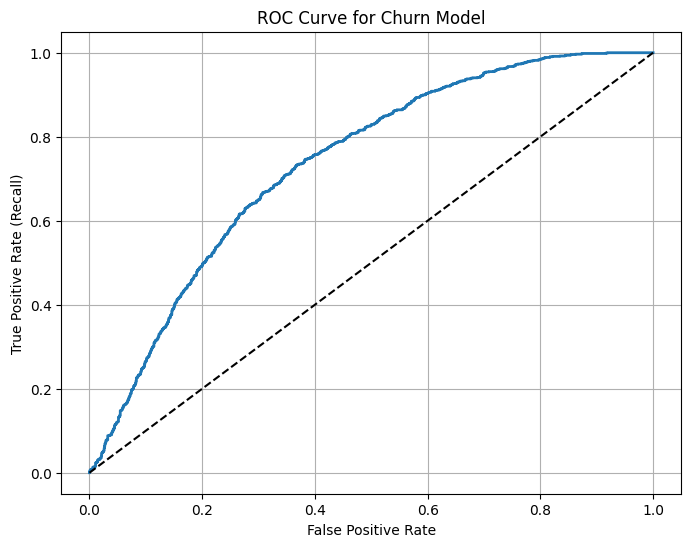

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0, 1], [0, 1], 'k--')  # Random classifier

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve for Churn Model")
plt.grid(True)

plt.show()

### Interpretation

- A curve closer to the top-left corner indicates better performance
- The diagonal line represents a random classifier
- The AUC score summarizes the model’s overall ability to distinguish between classes

Although the ROC AUC is useful, it can be misleading in imbalanced datasets like churn prediction.

Therefore, we rely more on Precision-Recall and threshold tuning for business decisions.

In [54]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_train, y_scores)
roc_auc

0.7346754896945493

In [55]:
from sklearn.svm import SVC

svc = SVC(probability=True)  

In [56]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ('lr', log_reg),
        ('rf', best_rf_model),
        ('svc', svc)
    ],
    voting='hard'
)

voting_clf.fit(X_train, y_train)

,estimators,"[('lr', ...), ('rf', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [57]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(voting_clf, X_train, y_train, cv=5, scoring='accuracy')
scores.mean()

np.float64(0.6885203481533757)

In [58]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score

y_pred_cv = cross_val_predict(voting_clf, X_train, y_train, cv=5)


In [59]:
precision_score(y_train, y_pred_cv)

0.6199842643587726

In [60]:
recall_score(y_train, y_pred_cv)

0.6822510822510822

In [61]:
voting_clf_soft = VotingClassifier(
    estimators=[
        ('lr', log_reg),
        ('rf', best_rf_model),
        ('svc', svc)
    ],
    voting='soft'
)

voting_clf_soft.fit(X_train, y_train)

,estimators,"[('lr', ...), ('rf', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [62]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(voting_clf_soft, X_train, y_train, cv=5, scoring='accuracy')
scores.mean()

np.float64(0.6903565547602245)

In [63]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score

y_pred_soft_cv = cross_val_predict(voting_clf_soft, X_train, y_train, cv=5)


In [64]:
precision_score(y_train, y_pred_soft_cv)

0.6297229219143576

In [65]:
recall_score(y_train, y_pred_soft_cv)

0.6493506493506493

In [66]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(random_state=42)

In [67]:
from sklearn.model_selection import cross_val_score

tree_scores = cross_val_score(tree_clf, X_train, y_train, cv=5, scoring='accuracy')
tree_scores.mean()

np.float64(0.5943630070235575)

In [68]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score

y_pred_tree = cross_val_predict(tree_clf, X_train, y_train, cv=5)

print("Decision Tree:")
print("Precision:", precision_score(y_train, y_pred_tree))
print("Recall:", recall_score(y_train, y_pred_tree))
print("F1:", f1_score(y_train, y_pred_tree))

Decision Tree:
Precision: 0.5215439856373429
Recall: 0.503030303030303
F1: 0.5121198765976201


In [69]:
from sklearn.ensemble import BaggingClassifier

bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=200,
    max_samples=0.8,
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)

Out-of-Bag (OOB) evaluation was used as an internal validation technique in the Bagging model.

Since each tree is trained on a bootstrap sample, approximately 37% of the training instances are not used for training each tree. These unused instances (OOB samples) are leveraged to estimate model performance without requiring a separate validation set.

This provides an efficient and unbiased estimate of the model’s generalization ability.

In [70]:
bag_clf.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,n_estimators,200
,max_samples,0.8
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,True
,warm_start,False
,n_jobs,-1
,random_state,42
,verbose,0


In [71]:
bag_scores = cross_val_score(bag_clf, X_train, y_train, cv=5, scoring='accuracy')
bag_scores.mean()

np.float64(0.6628719292939478)

In [72]:
y_pred_bag = cross_val_predict(bag_clf, X_train, y_train, cv=5)

print("Bagging:")
print("Precision:", precision_score(y_train, y_pred_bag))
print("Recall:", recall_score(y_train, y_pred_bag))
print("F1:", f1_score(y_train, y_pred_bag))

Bagging:
Precision: 0.6061427280939476
Recall: 0.580952380952381
F1: 0.5932802829354553


In addition to sampling training instances, ensemble methods can also sample features to increase model diversity.

This approach, known as random subspaces or random patches, reduces correlation between individual predictors, which helps lower variance and improve generalization.

Random Forest naturally incorporates this concept by selecting a random subset of features at each split, making it more effective than standard bagging.

Random Forest is an ensemble learning method that builds multiple decision trees using both bootstrap sampling (bagging) and random feature selection.

At each split, a random subset of features is considered instead of evaluating all features, which increases diversity among trees and reduces correlation.

This leads to lower variance and improved generalization compared to standard bagging.

In our project, Random Forest outperformed Bagging due to this additional randomness, achieving better recall and overall performance.

In [74]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score

extra_clf = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

y_pred_extra = cross_val_predict(extra_clf, X_train, y_train, cv=5)

print("Extra Trees:")
print("Precision:", precision_score(y_train, y_pred_extra))
print("Recall:", recall_score(y_train, y_pred_extra))

Extra Trees:
Precision: 0.6014692378328742
Recall: 0.5670995670995671


Extra Trees is an extension of Random Forest that introduces additional randomness by selecting random thresholds for splitting, instead of searching for the optimal ones.

This increases diversity among trees, reduces variance, and significantly speeds up training.

Although this approach increases bias slightly, it can sometimes outperform Random Forest depending on the dataset.

In [75]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score

# model
ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    learning_rate=0.5,
    random_state=42
)

# CV accuracy
ada_scores = cross_val_score(ada_clf, X_train, y_train, cv=5, scoring='accuracy')
print("AdaBoost Accuracy:", ada_scores.mean())

# predictions
y_pred_ada = cross_val_predict(ada_clf, X_train, y_train, cv=5)

# metrics
print("AdaBoost:")
print("Precision:", precision_score(y_train, y_pred_ada))
print("Recall:", recall_score(y_train, y_pred_ada))
print("F1:", f1_score(y_train, y_pred_ada))

AdaBoost Accuracy: 0.6764331081762275
AdaBoost:
Precision: 0.6123966942148761
Recall: 0.6415584415584416
F1: 0.6266384778012685


AdaBoost was applied as a boosting method that sequentially focuses on misclassified instances.

The model achieved better performance than Bagging and Extra Trees, confirming its ability to reduce bias and improve learning on difficult cases.

However, it did not outperform ensemble methods like Voting or Random Forest, suggesting that diversity-based ensembles were more effective for this dataset.

In [76]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.metrics import precision_score, recall_score, f1_score

gb_clf = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# accuracy
gb_scores = cross_val_score(gb_clf, X_train, y_train, cv=5, scoring='accuracy')
print("Gradient Boosting Accuracy:", gb_scores.mean())

# predictions
y_pred_gb = cross_val_predict(gb_clf, X_train, y_train, cv=5)

print("Gradient Boosting:")
print("Precision:", precision_score(y_train, y_pred_gb))
print("Recall:", recall_score(y_train, y_pred_gb))
print("F1:", f1_score(y_train, y_pred_gb))

Gradient Boosting Accuracy: 0.6848560002688443
Gradient Boosting:
Precision: 0.624262847514743
Recall: 0.6415584415584416
F1: 0.6327924850555081


In [85]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.metrics import precision_score, recall_score, f1_score

gb_clf_e = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    n_iter_no_change=10,
    validation_fraction=0.1,
    random_state=42
)

# accuracy
gbe_scores = cross_val_score(gb_clf_e, X_train, y_train, cv=5, scoring='accuracy')
print("Gradient Boosting Accuracy:", gbe_scores.mean())

# predictions
y_pred_gbe = cross_val_predict(gb_clf_e, X_train, y_train, cv=5)

print("Gradient Boosting:")
print("Precision:", precision_score(y_train, y_pred_gbe))
print("Recall:", recall_score(y_train, y_pred_gbe))
print("F1:", f1_score(y_train, y_pred_gbe))

Gradient Boosting Accuracy: 0.6907248714588163
Gradient Boosting:
Precision: 0.634167385677308
Recall: 0.6363636363636364
F1: 0.6352636127917026


In [86]:
gb_clf_e.n_estimators

500

In [87]:
from sklearn.ensemble import StackingClassifier

stack_clf = StackingClassifier(
    estimators=[
        ('lr', log_reg),                
        ('rf', best_rf_model),         
        ('svc', SVC(probability=True, random_state=42))
    ],
    final_estimator=LogisticRegression(),
    cv=5
)

stack_clf.fit(X_train, y_train)

,estimators,"[('lr', ...), ('rf', ...), ...]"
,final_estimator,LogisticRegression()
,cv,5
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [88]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score

y_pred_stack = cross_val_predict(stack_clf, X_train, y_train, cv=5)

print("Stacking:")
print("Precision:", precision_score(y_train, y_pred_stack))
print("Recall:", recall_score(y_train, y_pred_stack))

Stacking:
Precision: 0.6375321336760925
Recall: 0.6441558441558441


In [89]:
print("=== Comparison ===")

print("\nDecision Tree")
print(precision_score(y_train, y_pred_tree), recall_score(y_train, y_pred_tree))

print("\nBagging")
print(precision_score(y_train, y_pred_bag), recall_score(y_train, y_pred_bag))

print("\nRandom Forest")
print(precision_score(y_train,y_train_pred_rf), recall_score(y_train, y_train_pred_rf))

print("\nHard voting")
print(precision_score(y_train, y_pred_cv), recall_score(y_train,y_pred_cv))

print("\nSoft voting")
print(precision_score(y_train, y_pred_soft_cv), recall_score(y_train, y_pred_soft_cv))

print("\nExtra Trees")
print(precision_score(y_train, y_pred_extra), recall_score(y_train, y_pred_extra))

print("\nAdaBoost")
print(precision_score(y_train, y_pred_ada), recall_score(y_train, y_pred_ada))

print("\nGradient Boosting")
print(precision_score(y_train, y_pred_gbe), recall_score(y_train, y_pred_gbe))

print("\nStacking")
print(precision_score(y_train,y_pred_stack), recall_score(y_train, y_pred_stack))


=== Comparison ===

Decision Tree
0.5215439856373429 0.503030303030303

Bagging
0.6061427280939476 0.580952380952381

Random Forest
0.6239168110918544 0.6233766233766234

Hard voting
0.6199842643587726 0.6822510822510822

Soft voting
0.6297229219143576 0.6493506493506493

Extra Trees
0.6014692378328742 0.5670995670995671

AdaBoost
0.6123966942148761 0.6415584415584416

Gradient Boosting
0.634167385677308 0.6363636363636364

Stacking
0.6375321336760925 0.6441558441558441


We tested multiple ensemble methods.

Hard Voting achieved the highest recall, making it suitable for capturing most churn cases.

Stacking provided the best precision and balanced performance.

Depending on business priorities, we can choose between maximizing recall (Hard Voting) or maintaining a balance (Stacking).

In [97]:
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import cross_val_predict


y_scores_soft = cross_val_predict(
    voting_clf_soft,
    X_train,
    y_train,
    cv=5,
    method="predict_proba"
)


y_scores_soft = y_scores_soft[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores_soft)

In [ ]:
valid_idx = np.where(recalls >= 0.7)[0]
idx_recall_soft = valid_idx[-1]
threshold_recall_soft = thresholds[idx_recall]

threshold_recall_soft

np.float64(0.4710303014681658)

In [99]:
y_train_pred_recall_soft = (y_scores_soft >= threshold_recall_soft)

print("Precision:", precision_score(y_train, y_train_pred_recall_soft))
print("Recall:", recall_score(y_train, y_train_pred_recall_soft))
print("F1:", f1_score(y_train, y_train_pred_recall_soft))

Precision: 0.6189747513389442
Recall: 0.7004329004329004
F1: 0.6571892770105605


In [100]:
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import cross_val_predict


y_scores_gb = cross_val_predict(
    gb_clf_e,
    X_train,
    y_train,
    cv=5,
    method="predict_proba"
)


y_scores_gb = y_scores_gb[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores_gb)


In [ ]:
valid_idx = np.where(recalls >= 0.7)[0]
idx_recall_gb = valid_idx[-1]
threshold_recall_gb = thresholds[idx_recall]

threshold_recall_gb

np.float64(0.45965331749864874)

In [102]:
y_train_pred_recall_gb = (y_scores_gb >= threshold_recall_gb)

print("Precision:", precision_score(y_train, y_train_pred_recall_gb))
print("Recall:", recall_score(y_train, y_train_pred_recall_gb))
print("F1:", f1_score(y_train, y_train_pred_recall_gb))

Precision: 0.6161462300076161
Recall: 0.7004329004329004
F1: 0.6555915721231766


In [103]:
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import cross_val_predict


y_scores_stack = cross_val_predict(
    stack_clf,
    X_train,
    y_train,
    cv=5,
    method="predict_proba"
)


y_scores_stack = y_scores_stack[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores_stack)



In [112]:
valid_idx = np.where(recalls >= 0.7)[0]
idx_recall_stack = valid_idx[-1]
threshold_recall_stack = thresholds[idx_recall]

threshold_recall_stack

np.float64(0.4578192453124588)

In [113]:
y_train_pred_recall_stack = (y_scores_stack >= threshold_recall_stack)

print("Precision:", precision_score(y_train, y_train_pred_recall_stack))
print("Recall:", recall_score(y_train, y_train_pred_recall_stack))
print("F1:", f1_score(y_train, y_train_pred_recall_stack))

Precision: 0.6199233716475095
Recall: 0.7004329004329004
F1: 0.6577235772357723


Models were first compared using the default classification threshold to ensure a fair baseline comparison.

After selecting the top candidates, threshold tuning was applied to align model behavior with the business objective of maximizing churn detection.

Among the tuned models, Stacking achieved the best overall performance, reaching approximately 70% recall while maintaining the highest precision and F1-score. Therefore, it was selected as the final churn prediction model.

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

results = []

# Decision Tree
results.append({
    "Model": "Decision Tree",
    "Precision": precision_score(y_train, y_pred_tree),
    "Recall": recall_score(y_train, y_pred_tree),
    "F1": f1_score(y_train, y_pred_tree)
})

# Bagging
results.append({
    "Model": "Bagging",
    "Precision": precision_score(y_train, y_pred_bag),
    "Recall": recall_score(y_train, y_pred_bag),
    "F1": f1_score(y_train, y_pred_bag)
})

# Random Forest (TUNED)
results.append({
    "Model": "Random Forest (Tuned)",
    "Precision": precision_score(y_train, y_train_pred_recall),
    "Recall": recall_score(y_train, y_train_pred_recall),
    "F1": f1_score(y_train, y_train_pred_recall)
})

# Hard Voting
results.append({
    "Model": "Hard Voting",
    "Precision": precision_score(y_train, y_pred_cv),
    "Recall": recall_score(y_train, y_pred_cv),
    "F1": f1_score(y_train, y_pred_cv)
})

# Soft Voting (TUNED)
results.append({
    "Model": "Soft Voting (Tuned)",
    "Precision": precision_score(y_train, y_train_pred_recall_soft),
    "Recall": recall_score(y_train, y_train_pred_recall_soft),
    "F1": f1_score(y_train, y_train_pred_recall_soft)
})

# Extra Trees
results.append({
    "Model": "Extra Trees",
    "Precision": precision_score(y_train, y_pred_extra),
    "Recall": recall_score(y_train, y_pred_extra),
    "F1": f1_score(y_train, y_pred_extra)
})

# AdaBoost
results.append({
    "Model": "AdaBoost",
    "Precision": precision_score(y_train, y_pred_ada),
    "Recall": recall_score(y_train, y_pred_ada),
    "F1": f1_score(y_train, y_pred_ada)
})

# Gradient Boosting (TUNED)
results.append({
    "Model": "Gradient Boosting (Tuned)",
    "Precision": precision_score(y_train, y_train_pred_recall_gb),
    "Recall": recall_score(y_train, y_train_pred_recall_gb),
    "F1": f1_score(y_train, y_train_pred_recall_gb)
})

# Stacking (TUNED)
results.append({
    "Model": "Stacking (Tuned)",
    "Precision": precision_score(y_train, y_train_pred_recall_stack),
    "Recall": recall_score(y_train, y_train_pred_recall_stack),
    "F1": f1_score(y_train, y_train_pred_recall_stack)
})


df_results = pd.DataFrame(results)


df_results = df_results.sort_values(by="F1", ascending=False)

df_results

,Model,Precision,Recall,F1
8,Stacking (Tuned),0.619923,0.700433,0.657724
4,Soft Voting (Tuned),0.618975,0.700433,0.657189
7,Gradient Boosting (Tuned),0.616146,0.700433,0.655592
2,Random Forest (Tuned),0.616146,0.700433,0.655592
3,Hard Voting,0.619984,0.682251,0.649629
6,AdaBoost,0.612397,0.641558,0.626638
1,Bagging,0.606143,0.580952,0.593280
5,Extra Trees,0.601469,0.567100,0.583779
0,Decision Tree,0.521544,0.503030,0.512120


In [107]:
df_results.style.format({
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1": "{:.3f}"
}).background_gradient(cmap="Blues")

,Model,Precision,Recall,F1
8,Stacking (Tuned),0.620,0.700,0.658
4,Soft Voting (Tuned),0.619,0.700,0.657
7,Gradient Boosting (Tuned),0.616,0.700,0.656
2,Random Forest (Tuned),0.616,0.700,0.656
3,Hard Voting,0.620,0.682,0.650
6,AdaBoost,0.612,0.642,0.627
1,Bagging,0.606,0.581,0.593
5,Extra Trees,0.601,0.567,0.584
0,Decision Tree,0.522,0.503,0.512


In [108]:
best_model = df_results.iloc[0]
print("Best Model:")
print(best_model)

Best Model:
Model        Stacking (Tuned)
Precision            0.619923
Recall               0.700433
F1                   0.657724
Name: 8, dtype: object


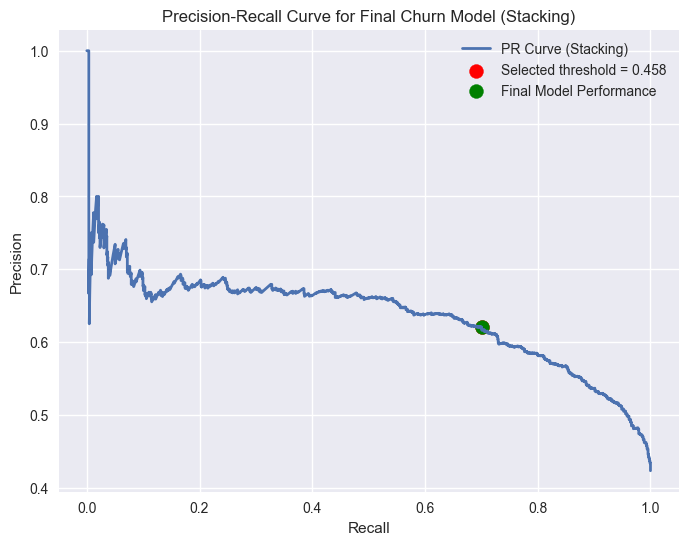

In [115]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

idx_selected = idx_recall_stack 

plt.figure(figsize=(8, 6))


plt.plot(recalls, precisions, linewidth=2, label="PR Curve (Stacking)")


plt.scatter(
    recalls[idx_selected],
    precisions[idx_selected],
    color="red",
    s=100,
    label=f"Selected threshold = {threshold_recall_stack:.3f}"
)

plt.scatter(
    recall_score(y_train, y_train_pred_recall_stack),
    precision_score(y_train, y_train_pred_recall_stack),
    color="green",
    s=100,
    label="Final Model Performance"
)

# labels
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Final Churn Model (Stacking)")
plt.legend()
plt.grid(True)

plt.show()

The Precision-Recall curve shows the trade-off between precision and recall for the final stacking model. 

A threshold was selected to achieve approximately 70% recall, aligning with the business objective of identifying most churn-risk customers. 

At this threshold, the model maintains a strong precision level, ensuring that the number of false positives remains controlled.

In [116]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train, y_scores_stack)

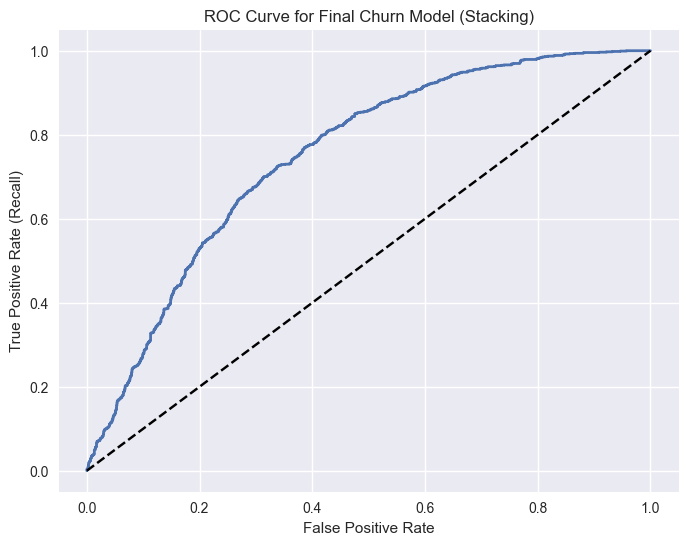

In [118]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0, 1], [0, 1], 'k--')  # Random classifier

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve for Final Churn Model (Stacking)")
plt.grid(True)

plt.show()